# Patryk Kożuch - lab 6

In [5]:
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"

## Download the dataset

In [37]:
from datasets import load_dataset, Dataset

dataset = load_dataset('PolyAI/banking77', trust_remote_code=True)

### Explore the dataset

In [7]:
import pandas as pd

df_train = dataset['train'].to_pandas()
df_test = dataset['test'].to_pandas()

df_full = pd.concat([df_train, df_test], ignore_index=True)

In [8]:
print("Length of training set:", len(df_train))
print("Length of test set:", len(df_test))

Length of training set: 10003
Length of test set: 3080


In [9]:
df_full

,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11
...,...,...
13078,"If i'm not in the UK, can I still get a card?",24
13079,How many countries do you support?,24
13080,What countries do you do business in?,24
13081,What are the countries you operate in.,24


In [10]:
df_full.dtypes

text     object
label     int64
dtype: object

In [11]:
print("None count in 'text' column:", df_full['text'].isna().sum())
print("None count in 'label' column:", df_full['label'].isna().sum())

None count in 'text' column: 0
None count in 'label' column: 0


In [12]:
df_full['text'].value_counts().head(10)

text
I am still waiting on my card?                                                                                                                         1
My transfer is pending too long.                                                                                                                       1
Why is  my balance not updated?                                                                                                                        1
I'm wondering how long it takes for my money to get to me after a bank transfer.                                                                       1
Hi. About two hours ago I made a transfer from my bank which is in the UK, but I don't see it yet! Would you check what's going on with it, please?    1
When does a UK transfer show up?                                                                                                                       1
I do not see the money I transferred into this account                       

There are no empty or missing values in the dataset.

<Axes: >

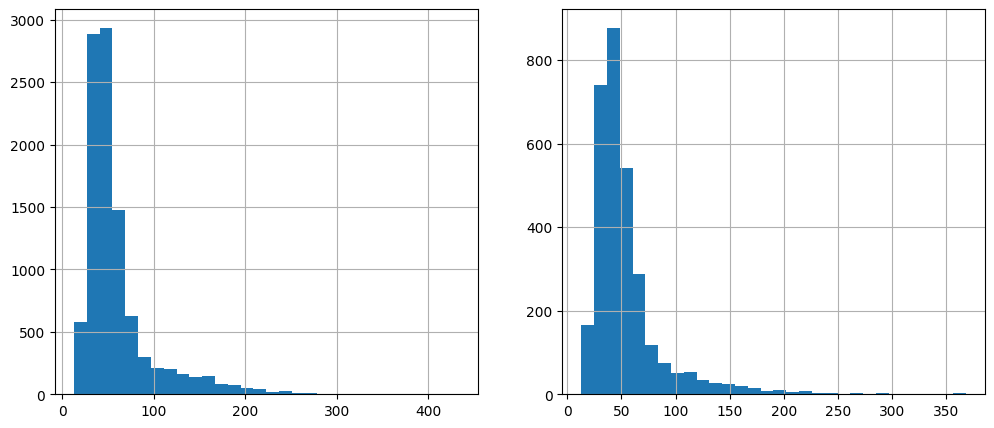

In [13]:
from matplotlib import pyplot as plt

f, ax = plt.subplots(1, 2, figsize=(12, 5))

df_train['text'].str.len().hist(ax=ax[0], bins=30)
df_test['text'].str.len().hist(ax=ax[1], bins=30)

Distribution of text length in training and test sets looks similar.

<Axes: title={'center': 'Test dataset'}>

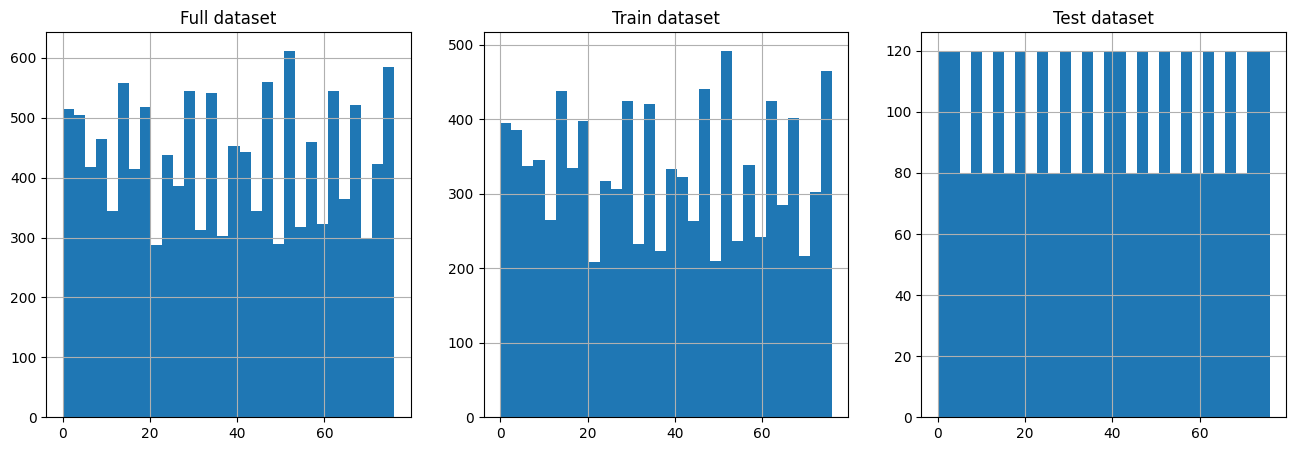

In [14]:
from matplotlib import pyplot as plt

f, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].set_title('Full dataset')
df_full['label'].hist(ax=ax[0], bins=30)
ax[1].set_title('Train dataset')
df_train['label'].hist(ax=ax[1], bins=30)
ax[2].set_title('Test dataset')
df_test['label'].hist(ax=ax[2], bins=30)

However, the distribution of labels is different in training and test sets - test set is more (but not completely) balanced. In training data there is a visible dominance of some labels over others.

## Cleanup labels

In [15]:
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict


def get_initial_model_data(texts: np.ndarray, labels: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = model.encode(texts, show_progress_bar=True, convert_to_numpy=True)
    clf = LogisticRegression(max_iter=1000, random_state=0, class_weight="balanced")
    pred_probs = cross_val_predict(
        clf,
        embeddings,
        labels,
        cv=5,
        method="predict_proba",
        n_jobs=-1,
    )

    return embeddings, pred_probs

### Examine train data

In [16]:
texts = df_full["text"].values
labels = df_full["label"].values

embeddings, pred_probs = get_initial_model_data(texts, labels)

Batches:   0%|          | 0/409 [00:00<?, ?it/s]

In [17]:
from cleanlab import Datalab


data_dict = {"texts": texts, "labels": labels}
lab = Datalab(data_dict, label_name="labels", task="classification")
lab.find_issues(pred_probs=pred_probs, features=embeddings)
lab.report()

Finding null issues ...
Finding label issues ...
Finding outlier issues ...
Finding near_duplicate issues ...
Finding non_iid issues ...
Finding class_imbalance issues ...
Finding underperforming_group issues ...

Audit complete. 865 issues found in the dataset.
Dataset Information: num_examples: 13083, num_classes: 77

Here is a summary of various issues found in your data:

    issue_type  num_issues
near_duplicate         513
         label         187
       outlier         164
       non_iid           1

Learn about each issue: https://docs.cleanlab.ai/stable/cleanlab/datalab/guide/issue_type_description.html
See which examples in your dataset exhibit each issue via: `datalab.get_issues(<ISSUE_NAME>)`

Data indices corresponding to top examples of each issue are shown below.


------------------ near_duplicate issues -------------------

About this issue:
	A (near) duplicate issue refers to two or more examples in
    a dataset that are extremely similar to each other, relative
  

### Duplicates

In [18]:
duplicate_issues = lab.get_issues("near_duplicate")
duplicate_issues = duplicate_issues[duplicate_issues["is_near_duplicate_issue"]]
duplicate_issues = duplicate_issues.sort_values(by="near_duplicate_score")

In [19]:
for idx, row in duplicate_issues.head(10).iterrows():
    text = texts[idx]
    neighbors = texts[row["near_duplicate_sets"][:3]]
    print(f"Text: {text}")
    print(f"\tDuplicates: {neighbors}")
    print()

Text: I don't live in the UK.  Can I still get a card?
	Duplicates: ["I don't live in the UK. Can I still get a card?"]

Text: Which ATMs accept this card?
	Duplicates: ['\nWhich ATMs accept this card?']

Text: There are a few transaction that I don't recognize, I think someone managed to get my card details and use it.
	Duplicates: ["There are a few transaction that I don't recognize, I think someone managed to get my card details and use it.\n"]

Text: How do I change my address?
	Duplicates: ['How do I change my address ?']

Text: Where can I use my card?
	Duplicates: ['\nWhere can I use my card?']

Text: 

What businesses accept this card?
	Duplicates: ['What businesses accept this card?']

Text: How do I unblock my PIN?
	Duplicates: ['\nHow do I unblock my PIN?' 'How can I unblock my PIN?'
 'How to unblock my PIN?']

Text: Why do you keep declining my payment? I tried several times already with this card and it is just not working.
	Duplicates: ['Why do you keep declining my payme

These duplicates look like true duplicates - i.e. the form was submitted multiple times with the same or very similar text. They are worth removing from the training set.

In [20]:
df_full["text_lower"] = df_full["text"].str.lower()
df_full_deduplicated = df_full.drop_duplicates(subset="text_lower")
df_full_deduplicated = df_full_deduplicated.drop(columns="text_lower")
df_full_deduplicated = df_full_deduplicated.reset_index(drop=True)
df_full_deduplicated

,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11
...,...,...
13078,"If i'm not in the UK, can I still get a card?",24
13079,How many countries do you support?,24
13080,What countries do you do business in?,24
13081,What are the countries you operate in.,24


### Mislabeled examples

In [21]:
class_names = dataset['train'].info.features['label'].names

In [22]:
label_issues = lab.get_issues("label")
label_issues = label_issues[label_issues["is_label_issue"]]
label_issues = label_issues.sort_values(by="label_score")

top_label_issues_y_true = label_issues.head(5)["given_label"].map(lambda x: class_names[x])
top_label_issues_y_pred = label_issues.head(5)["predicted_label"].map(lambda x: class_names[x])
top_label_issues_score = label_issues.head(5)["label_score"]
top_label_issues_idxs = label_issues.head(5).index
top_label_issues_texts = texts[top_label_issues_idxs]

print("Top 5 label issues")
for text, y_true, y_pred, score in zip(top_label_issues_texts, top_label_issues_y_true, top_label_issues_y_pred, top_label_issues_score):
    print(f"y_true: '{y_true}', y_pred: '{y_pred}', \nscore: {score},\ntext: {text}")
    print()

Top 5 label issues
y_true: 'compromised_card', y_pred: 'lost_or_stolen_card', 
score: 0.006804509249779042,
text: How do I order a replacement for stolen card?

y_true: 'transfer_into_account', y_pred: 'topping_up_by_card', 
score: 0.007495162497345386,
text: How do I top up my card?

y_true: 'top_up_failed', y_pred: 'declined_card_payment', 
score: 0.007942254230789175,
text: My credit card transaction was declined for a loan payment.  Can you tell me why?

y_true: 'declined_cash_withdrawal', y_pred: 'card_not_working', 
score: 0.008545471934736067,
text: Is my card actually working? It's the first time I tried using it

y_true: 'pending_transfer', y_pred: 'balance_not_updated_after_bank_transfer', 
score: 0.010377978715641922,
text: I have not seen any changes in my account balance(s) after making a transfer.



Let's analyze top 5 issues:

> "How do I order a replacement for stolen card?"

It is labeled as **"compromised_card"** - predicted as **"lost_or_stolen_card"**. In this case both labels are acceptable, but the predicted label seems to be more specific.

> "How do I top up my card?"

Similar issue to the previous one. It is labeled as **"transfer_into_account"** - predicted as **"topping_up_by_card"**. Both labels are acceptable, but the predicted label seems to be more specific.

> "My credit card transaction was declined for a loan payment.  Can you tell me why?"

It is labeled as **"top_up_failed"** - predicted as **"declined_card_payment"**. The ground truth label is completely incorrect - there is nothing about the top-up in the text.

> "Is my card actually working? It's the first time I tried using it"

It is labeled as **"declined_cash_withdrawal"** - predicted as **"card_not_working"**. Similar to the previous case - there is nothing about cash withdrawal in the text, so the predicted label seems to be more appropriate.

> "I have not seen any changes in my account balance(s) after making a transfer."

It is labeled as **"pending_transfer"** - predicted as **"balance_not_updated_after_bank_transfer"**. Both labels are acceptable.



In most of the investigated cases the predicted label seems to be more appropriate than the ground truth label. And in the cases where both labels are acceptable, chaning to predicted label won't hurt. So, I would go with changing the labels to the predicted ones.

In [23]:
top_error_labels = label_issues["given_label"].copy()
top_error_labels = top_error_labels.map(lambda x: class_names[x])
top_error_labels.value_counts()

given_label
top_up_reverted                            15
balance_not_updated_after_bank_transfer    14
pending_transfer                           11
declined_transfer                          10
reverted_card_payment?                      7
supported_cards_and_currencies              7
wrong_exchange_rate_for_cash_withdrawal     7
card_arrival                                7
pending_top_up                              7
beneficiary_not_allowed                     7
top_up_failed                               7
card_delivery_estimate                      6
transfer_timing                             6
card_not_working                            5
declined_cash_withdrawal                    5
why_verify_identity                         5
transfer_not_received_by_recipient          4
compromised_card                            4
lost_or_stolen_card                         4
get_disposable_virtual_card                 4
lost_or_stolen_phone                        4
top_up_by_cash_or_cheq

The results mainly agree with the paper, with "top_up_reverted", "pending_top_up" and "balance_not_updated_after_bank_transfer" being one of the most common mislabeled classes.

### Outliers

In [24]:
outliers_issues = lab.get_issues("outlier")
outliers_issues = outliers_issues[outliers_issues["is_outlier_issue"]]
outliers_issues = outliers_issues.sort_values(by="outlier_score")

for idx, row in outliers_issues.head(10).iterrows():
    text = texts[idx]
    print(f"Text: {text}")
    print()

Text: WHAT IS THE ATMOSPHERE OF IT

Text: what is the word?

Text: What is this witdrawal

Text: what is the matter?

Text: WHAT IS THE SOLUTION OF THIS PROBLEM

Text: I prefer Mastecard.

Text: I have made 5 attempts to make a very standard survey, yet I can't get it to work. What is the problem? Is there an issue related to your system?

Text: WHAT IS THE REASON FOR THAT

Text: WHAT IS THE MAIN REASON OF THIS PROBLEM

Text: Is a copy of the police report necessary for completing the report process?



The outliers seem mainly to be unrelated to banking or too vague to assign a specific label. It is probably best to remove them from the training set.

#### Non-IID examples

In [25]:
non_iid_issues = lab.get_issues("non_iid")
non_iid_issues = non_iid_issues[non_iid_issues["is_non_iid_issue"]]
non_iid_issues = non_iid_issues.sort_values(by="non_iid_score")

for idx, row in non_iid_issues.head(10).iterrows():
    text = texts[idx]
    print(f"Text: {text}")
    print()

Text: Why hasn't my card been delivered?



As there is only one non-IID issue detected, I will not take any action on it.

In [26]:
label_issues = label_issues[label_issues.index.isin(df_full_deduplicated.index)]
outliers_issues = outliers_issues[outliers_issues.index.isin(df_full_deduplicated.index)]
idxs = label_issues.index.tolist()
pred_labels = label_issues["predicted_label"]

df_fixed = df_full_deduplicated.copy()
df_fixed.loc[idxs, "label"] = pred_labels
df_fixed = df_fixed.drop(index=outliers_issues.index)
df_fixed

,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11
...,...,...
13078,"If i'm not in the UK, can I still get a card?",24
13079,How many countries do you support?,24
13080,What countries do you do business in?,24
13081,What are the countries you operate in.,24


## Classifier

In [31]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, \
    DataCollatorWithPadding

model_name = "distilbert-base-uncased"
num_labels = len(class_names)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [61]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df_fixed, test_size=0.2, random_state=42, stratify=df_fixed['label'])
val_df, test_df = train_test_split(val_df, test_size=0.5, random_state=42, stratify=val_df['label'])

In [62]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [63]:
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return {"f1": f1_score(labels, predictions, average='weighted'), "accuracy": (predictions == labels).mean()}

In [64]:
train_dataset = Dataset.from_pandas(train_df).map(lambda x: tokenizer(x['text'], truncation=True), batched=True)
val_dataset = Dataset.from_pandas(val_df).map(lambda x: tokenizer(x['text'], truncation=True), batched=True)

Map:   0%|          | 0/10335 [00:00<?, ? examples/s]

Map:   0%|          | 0/1292 [00:00<?, ? examples/s]

In [65]:
trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="./results",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=10,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        metric_for_best_model="f1",
        load_best_model_at_end=True,
    ),
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.015700,0.264147,0.942016,0.941950


KeyboardInterrupt: 

In [66]:
from scipy.special import softmax
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

pred_output = trainer.predict(val_dataset)
logits = pred_output.predictions
labels = pred_output.label_ids
probs = softmax(logits, axis=1)
preds = np.argmax(logits, axis=1)

print(classification_report(labels, preds, target_names=class_names))

                                                  precision    recall  f1-score   support

                                activate_my_card       1.00      1.00      1.00        20
                                       age_limit       1.00      1.00      1.00        15
                         apple_pay_or_google_pay       1.00      1.00      1.00        16
                                     atm_support       0.92      1.00      0.96        12
                                automatic_top_up       1.00      0.88      0.93        16
         balance_not_updated_after_bank_transfer       1.00      0.90      0.95        21
balance_not_updated_after_cheque_or_cash_deposit       0.95      0.91      0.93        23
                         beneficiary_not_allowed       1.00      0.89      0.94        19
                                 cancel_transfer       0.90      1.00      0.95        19
                            card_about_to_expire       1.00      0.88      0.94        17
         

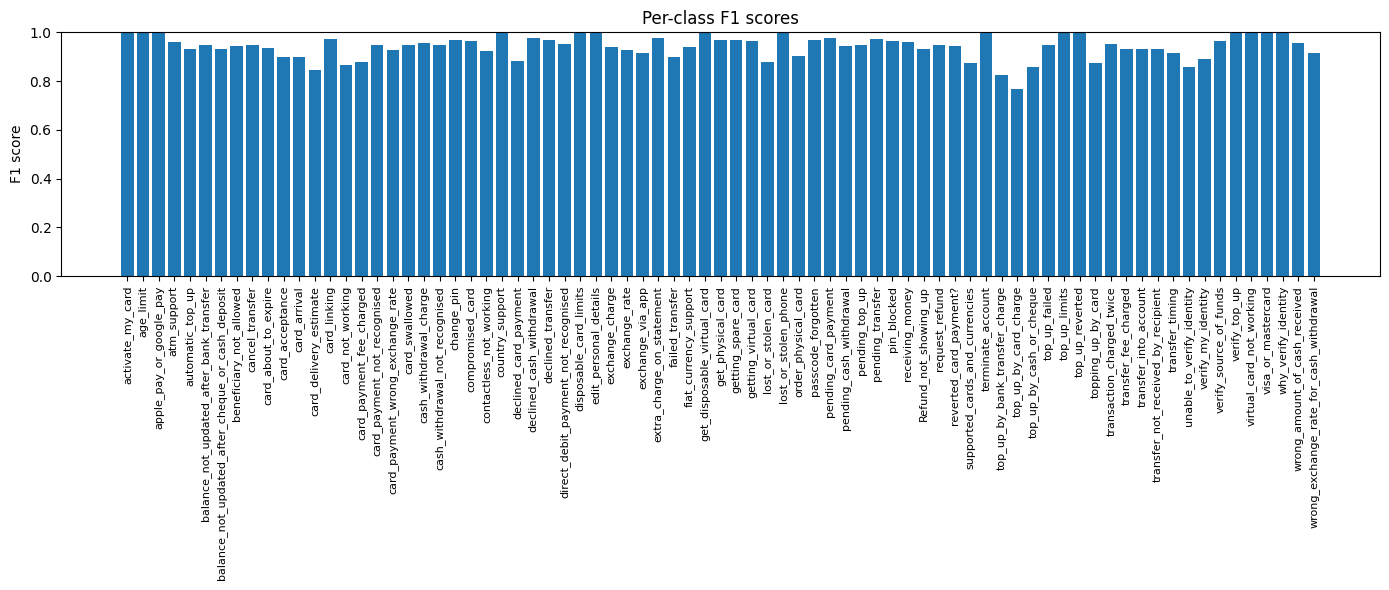

In [67]:
f1_per_class = f1_score(labels, preds, average=None)
x = np.arange(len(class_names))

plt.figure(figsize=(14, 6))

plt.bar(x, f1_per_class, color="C0")
plt.xticks(x, class_names, rotation=90, fontsize=8)
plt.ylim(0, 1.0)
plt.ylabel("F1 score")
plt.title("Per-class F1 scores")
plt.tight_layout()
plt.show()

The model has achieved a macro F1 score of about 0.94, which is even better than in the original paper (0.92). The per-class F1 scores however shows significant variation between classes, with some classes achieving 0.83 F1 score when the model can achieve perfect score on other classes.

For me, that is enough for the model to be considered good enough for practical use. However, there should be some hyperparameter tuning done to see if the performance on the imbalanced classes can be improved.

## Giskard

In [84]:
def preprocess(df):
    return tokenizer(
        df['text'].tolist(),
        truncation=True,
        padding=True,
        max_length=512,
        return_tensors="pt"
    ).to('cuda')

In [87]:
import torch
from giskard import Dataset as GiskardDataset, scan
from giskard.models.huggingface import HuggingFaceModel

trained_model = trainer.model
trained_model.eval()
trained_model.to(torch.device("cuda"))

giskard_dataset = GiskardDataset(test_df, target="label")

giskard_model = HuggingFaceModel(
    model=trained_model,
    model_type="classification",
    data_preprocessing_function=preprocess,
    classification_labels=list(range(num_labels)),
    feature_names=["text"],
    device="cuda"
)
scan_results = scan(giskard_model, giskard_dataset, verbose=False)
display(scan_results)

2025-12-01 22:43:10,640 pid:4317 MainThread giskard.datasets.base INFO     Your 'pandas.DataFrame' is successfully wrapped by Giskard's 'Dataset' wrapper class.
2025-12-01 22:43:10,645 pid:4317 MainThread giskard.datasets.base INFO     Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
2025-12-01 22:43:10,671 pid:4317 MainThread giskard.utils.logging_utils INFO     Predicted dataset with shape (10, 2) executed in 0:00:00.029676
2025-12-01 22:43:10,676 pid:4317 MainThread giskard.datasets.base INFO     Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
2025-12-01 22:43:10,679 pid:4317 MainThread giskard.utils.logging_utils INFO     Predicted dataset with shape (1, 2) executed in 0:00:00.006255
2025-12-01 22:43:10,682 pid:4317 MainThread giskard.datasets.base INFO     Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
2025-12-01 22:43:10,682 pid:4317 MainThread giskard.utils.logging_utils INFO     Predicted dataset with shape

<iframe id="scan-139868206926288" srcdoc="<!doctype html>
<html lang="en">

<head>
 <title>Giskard Scan Results</title>
 <base target="_blank">
 <meta charset="utf-8">
 
<style>pre code.hljs{display:block;overflow-x:auto;padding:1em}code.hljs{padding:3px 5px}
/*!
 Theme: GitHub Dark
 Description: Dark theme as seen on github.com
 Author: github.com
 Maintainer: @Hirse
 Updated: 2021-05-15

 Outdated base version: https://github.com/primer/github-syntax-dark
 Current colors taken from GitHub's CSS
*/.hljs{background:#0d1117;color:#c9d1d9}.hljs-doctag,.hljs-keyword,.hljs-meta .hljs-keyword,.hljs-template-tag,.hljs-template-variable,.hljs-type,.hljs-variable.language_{color:#ff7b72}.hljs-title,.hljs-title.class_,.hljs-title.class_.inherited__,.hljs-title.function_{color:#d2a8ff}.hljs-attr,.hljs-attribute,.hljs-literal,.hljs-meta,.hljs-number,.hljs-operator,.hljs-selector-attr,.hljs-selector-class,.hljs-selector-id,.hljs-variable{color:#79c0ff}.hljs-meta .hljs-string,.hljs-regexp,.hljs-string{color:#a5d6ff}.hljs-built_in,.hljs-symbol{color:#ffa657}.hljs-code,.hljs-comment,.hljs-formula{color:#8b949e}.hljs-name,.hljs-quote,.hljs-selector-pseudo,.hljs-selector-tag{color:#7ee787}.hljs-subst{color:#c9d1d9}.hljs-section{color:#1f6feb;font-weight:700}.hljs-bullet{color:#f2cc60}.hljs-emphasis{color:#c9d1d9;font-style:italic}.hljs-strong{color:#c9d1d9;font-weight:700}.hljs-addition{background-color:#033a16;color:#aff5b4}.hljs-deletion{background-color:#67060c;color:#ffdcd7}.hljs-copy-wrapper{overflow:hidden;position:relative}.hljs-copy-button:focus,.hljs-copy-wrapper:hover .hljs-copy-button{transform:translateX(0)}.hljs-copy-button{background-color:#2d2b57;background-color:var(--hljs-theme-background);background-image:url('data:image/svg+xml;charset=utf-8,<svg xmlns="http://www.w3.org/2000/svg" width="16" height="16" fill="none" viewBox="0 0 24 24"><path fill="%23fff" fill-rule="evenodd" d="M6 5a1 1 0 0 0-1 1v14a1 1 0 0 0 1 1h12a1 1 0 0 0 1-1V6a1 1 0 0 0-1-1h-2a1 1 0 1 1 0-2h2a3 3 0 0 1 3 3v14a3 3 0 0 1-3 3H6a3 3 0 0 1-3-3V6a3 3 0 0 1 3-3h2a1 1 0 0 1 0 2H6Z" clip-rule="evenodd"/><path fill="%23fff" fill-rule="evenodd" d="M7 3a2 2 0 0 1 2-2h6a2 2 0 0 1 2 2v2a2 2 0 0 1-2 2H9a2 2 0 0 1-2-2V3Zm8 0H9v2h6V3Z" clip-rule="evenodd"/></svg>');background-position:50%;background-repeat:no-repeat;border:1px solid #ffffff22;border-radius:.25rem;color:#fff;height:2rem;position:absolute;right:1em;text-indent:-9999px;top:1em;transition:background-color .2s ease,transform .2s ease-out;width:2rem}.hljs-copy-button:hover{border-color:#ffffff44}.hljs-copy-button:active{border-color:#ffffff66}.hljs-copy-button[data-copied=true]{background-image:none;text-indent:0;width:auto}@media (prefers-reduced-motion){.hljs-copy-button{transition:none}}.hljs-copy-alert{clip:rect(0 0 0 0);-webkit-clip-path:inset(50%);clip-path:inset(50%);height:1px;overflow:hidden;position:absolute;white-space:nowrap;width:1px}
/*! tailwindcss v3.3.2 | MIT License | https://tailwindcss.com*/*,:after,:before{border:0 solid #e5e7eb;box-sizing:border-box}:after,:before{--tw-content:""}html{-webkit-text-size-adjust:100%;font-feature-settings:normal;font-family:ui-sans-serif,system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,Roboto,Helvetica Neue,Arial,Noto Sans,sans-serif,Apple Color Emoji,Segoe UI Emoji,Segoe UI Symbol,Noto Color Emoji;font-variation-settings:normal;line-height:1.5;-moz-tab-size:4;-o-tab-size:4;tab-size:4}body{line-height:inherit;margin:0}hr{border-top-width:1px;color:inherit;height:0}abbr:where([title]){-webkit-text-decoration:underline dotted;text-decoration:underline dotted}h1,h2,h3,h4,h5,h6{font-size:inherit;font-weight:inherit}a{color:inherit;text-decoration:inherit}b,strong{font-weight:bolder}code,kbd,pre,samp{font-family:ui-monospace,SFMono-Regular,Menlo,Monaco,Consolas,Liberation Mono,Courier New,monospace;font-size:1em}small{font-size:80%}sub,sup{font-size:75%;line-height:0;position:relative;vertical-align:baseline}sub{bottom:-.25em}sup{top:-.5em}table{border-collaps

There are still some issues - the model is vulnerable to typos - it fails in over 26% of cases when a typo is introduced.

It is also biased against "rich and poor countries" - it fails in over 10% of cases when the high income country is switched to a low income country or vice versa.

It is also vulnerable to word "Money" - accuracy drops by over 7% (94% -> 87%) when the word "money" is removed from the text.

In [119]:
from copy import deepcopy

from captum.attr import InputXGradient, configure_interpretable_embedding_layer, LayerIntegratedGradients
from captum.attr import visualization as vis


class BERTModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, inputs, attention_mask):
        return self.model(inputs, attention_mask=attention_mask)[0]


def explain_text(model, text: str, y_true: int) -> None:
    # make sure we compute gradients as necessary
    for param in model.distilbert.parameters():
        param.requires_grad = True

    tokenizer_output = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        return_attention_mask=True,
        return_tensors="pt",
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer_output = tokenizer_output.to(device)
    tokens = tokenizer.convert_ids_to_tokens(tokenizer_output["input_ids"][0])
    ref_tokens = [tokenizer.pad_token_id] * len(tokens)
    model_copy = deepcopy(model)
    interpretable_embedding_layer = configure_interpretable_embedding_layer(
        model_copy, "distilbert.embeddings"
    )
    input_embeddings = interpretable_embedding_layer.indices_to_embeddings(
        tokenizer_output["input_ids"]
    )

    model_wrapper = BERTModelWrapper(model_copy)

    with torch.no_grad():
        logits = model(**tokenizer_output).logits
        pred_class = int(torch.argmax(logits, dim=1).item())
        y_pred_proba = softmax(logits.cpu(), axis=1)[0, pred_class].item()

    lig = LayerIntegratedGradients(model_wrapper, interpretable_embedding_layer)

    attributions = lig.attribute(
        input_embeddings,
        target=pred_class,
        additional_forward_args=tokenizer_output["attention_mask"],
    )

    # mean normalization
    attributions = attributions.sum(dim=-1).squeeze(0)
    attributions = attributions / torch.norm(attributions)
    attributions = list([float(attr) for attr in attributions])

    # remove [CLS] and [SEP] tokens
    attributions = attributions[1:-1]
    tokens = tokens[1:-1]

    vis_record = vis.VisualizationDataRecord(
        word_attributions=attributions,
        pred_prob=y_pred_proba,
        pred_class=pred_class,
        true_class=y_true,
        attr_class=pred_class,
        attr_score=sum(attributions),
        raw_input_ids=tokens,
        convergence_score=0,
    )
    vis.visualize_text([vis_record])

In [120]:
texts = test_df['text'].tolist()
labels = test_df['label'].tolist()

In [121]:
explain_text(trained_model, texts[0], labels[0])

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
59,59 (1.00),59,1.30,"my top - up failed , why ?"


In [124]:
class_names[labels[0]]

'top_up_failed'

Models focuses on 'top' and 'failed' words to predict 'top_up_failed' label.

In [122]:
explain_text(trained_model, texts[1], labels[1])

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
8,8 (1.00),8,1.56,how do i rev ##ert a transaction ?


In [125]:
class_names[labels[1]]

'cancel_transfer'

Model focuses on 'revert' and 'transaction' words to predict 'cancel_transaction' label - also correct.

In [123]:
explain_text(trained_model, texts[2], labels[2])

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
25,25 (1.00),25,1.65,explain the payment that was declined !


In [126]:
class_names[labels[2]]

'declined_card_payment'

Model focuses on 'declined' and 'payment' words to predict 'declined_card_payment' label - also perfectly correct.

Based on these three examples, it seems that the model is focusing on the correct words when making predictions.